In [1]:
import tensorflow as tf
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=tf.keras.datasets.mnist

In [3]:
(X_train,y_train),(X_test,y_test)=data.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
X_train.shape

(60000, 28, 28)

In [5]:
model=tf.keras.models.Sequential()

# CNN
model.add(tf.keras.layers.Conv2D(32,padding='valid',activation='relu',kernel_size=(3,3),input_shape=(28,28,1)))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(tf.keras.layers.Conv2D(32,padding='valid',activation='relu',kernel_size=(3,3)))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(tf.keras.layers.Flatten())
# ANN

model.add(tf.keras.layers.Dense(16,activation='relu'))
model.add(tf.keras.layers.Dense(16,activation='relu'))
model.add(tf.keras.layers.Dense(10,activation='softmax'))

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,826 (89.16 KB)

 Trainable params: 22,826 (89.16 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
@tf.function
def train_step(X, y):
    with tf.GradientTape() as tape:
        pred = model(X, training=True)
        loss = loss_fn(y, pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

In [8]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

batch_size = 128
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
dataset = dataset.shuffle(X_train.shape[0]).batch(batch_size).prefetch(tf.data.AUTOTUNE) 

epochs = 40
loss_val=[]
for i in range(epochs):
    for X_batch, y_batch in dataset:
        loss = train_step(X_batch, y_batch)
    loss_val.append(loss)
    print("Epoch:", i+1, "Loss:", loss.numpy())

2026-03-18 10:48:50.868588: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch: 1 Loss: 2.0046494


2026-03-18 10:48:55.524687: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch: 2 Loss: 1.3312491
Epoch: 3 Loss: 0.96133685


2026-03-18 10:49:05.545751: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Epoch: 8 Loss: 0.04574727
Epoch: 9 Loss: 0.08248416
Epoch: 10 Loss: 0.0074797943
Epoch: 11 Loss: 0.04845972
Epoch: 12 Loss: 0.046224464
Epoch: 13 Loss: 0.010793392
Epoch: 14 Loss: 0.052692454
Epoch: 15 Loss: 0.027210483


2026-03-18 10:50:12.386668: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch: 16 Loss: 0.0060239737
Epoch: 17 Loss: 0.011376072
Epoch: 18 Loss: 0.0320885
Epoch: 19 Loss: 0.0034684746
Epoch: 20 Loss: 0.030242981
Epoch: 21 Loss: 0.0012974836
Epoch: 22 Loss: 0.0032656854
Epoch: 23 Loss: 0.004692253
Epoch: 24 Loss: 0.051464528
Epoch: 25 Loss: 0.043204773
Epoch: 26 Loss: 0.02353569
Epoch: 27 Loss: 0.009989487
Epoch: 28 Loss: 0.0007458443
Epoch: 29 Loss: 0.0004464636
Epoch: 30 Loss: 0.0024996053
Epoch: 31 Loss: 0.00066632003


2026-03-18 10:51:35.353200: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch: 32 Loss: 0.011368089
Epoch: 33 Loss: 0.00020891924
Epoch: 34 Loss: 0.0051779873
Epoch: 35 Loss: 0.029942384
Epoch: 36 Loss: 0.0018432607
Epoch: 37 Loss: 0.04275182
Epoch: 38 Loss: 5.5739347e-05
Epoch: 39 Loss: 0.0004437631
Epoch: 40 Loss: 0.012054041


In [9]:
accuracy=np.mean(np.argmax(model.predict(X_train),axis=1)==y_train)
print("Training Accuracy:", accuracy*100)
accuracy=np.mean(np.argmax(model.predict(X_test),axis=1)==y_test)
print("Testing Accuracy:", accuracy*100)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Training Accuracy: 99.75666666666667
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Testing Accuracy: 98.48


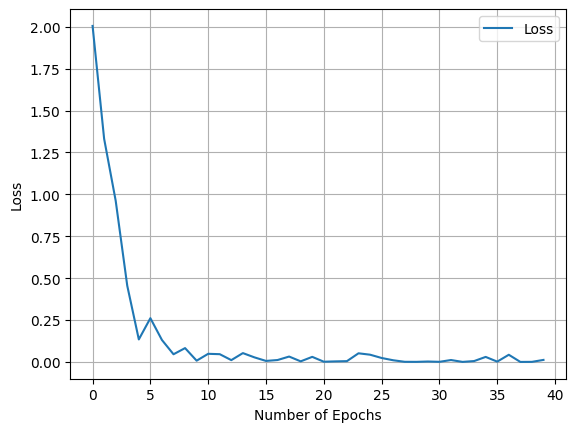

In [10]:
import matplotlib.pyplot as plt
plt.plot(loss_val,label='Loss')
plt.xlabel('Number of Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()